In [ ]:
from google.colab import drive
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


# Eﬀect of Different Feature Type on Model Performance

To partially reproduce the content of Table 3 from the paper, I tested four feature type combinations (Gene Expression & Sequence, Metabolic Network and FCA) under their respective optimal models to evaluate Performance, and plotted the ROC Curves.

The reason for doing this is that, among the 26 features, only 1-2 features related to RN and Expression were selected, which is much fewer compared to the number of features from other types. Therefore, I grouped and combined these features before proceeding with the analysis.

## Loading the Datasets

In [ ]:
import os
import re
import shutil
import random
import gc
from ast import literal_eval
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, recall_score, precision_score, f1_score,
                             matthews_corrcoef, roc_auc_score, roc_curve, auc)

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Define three different folder paths
project_folder = '/content/drive/MyDrive/CSI5180_Project'
results_folder = '/content/drive/MyDrive/CSI5180_Project/results'
best_model_folder = '/content/drive/MyDrive/CSI5180_Project/best_models'

# Read the two result files
summary_df = pd.read_csv(os.path.join(results_folder, 'summary_best_k.csv'))
feature_freq_df = pd.read_csv(os.path.join(results_folder, 'Feature_Frequency_Analysis.csv'))

# Convert the 'feature_rank' column in summary_df from a string to a list
summary_df['feature_rank'] = summary_df['feature_rank'].apply(literal_eval)

# Define dataset storage paths
drive_datasets_folder = '/content/drive/MyDrive/CSI5180_Project/balanced_datasets'
local_datasets_folder = '/content/balanced_datasets'

In [ ]:
# Ensure local directory exists
os.makedirs(local_datasets_folder, exist_ok=True)

# Copy all data from Google Drive to local storage
shutil.copytree(drive_datasets_folder, local_datasets_folder, dirs_exist_ok=True)

print("Data copied to /content/balanced_datasets. Training is no longer affected by Google Drive API limitations.")

Data copied to /content/balanced_datasets. Training is no longer affected by Google Drive API limitations.


In [ ]:
# Global feature type groups dictionary
feature_groups = {
    'Expression': ["NGSE"],
    'Sequence': ["PR", "H3", "H5", "Alaf", "Argf", "H7", "CAI", "Leuf", "GC1", "T3",
                   "Glyf", "Valf", "Serf", "Phef", "C3", "Gluf", "GC2", "Asnf"],
    'Expression_and_Sequence': ["NGSE", "PR", "H3", "H5", "Alaf", "Argf", "H7", "CAI", "Leuf", "GC1", "T3",
                                  "Glyf", "Valf", "Serf", "Phef", "C3", "Gluf", "GC2", "Asnf"],
    'RN': ["RN_CC", "RN_BC"],
    'FCA': ["FCA_AS", "FCA_num_triangles", "FCA_HS", "FCA_ClustCoef", "FCA_BC"],
    'RN_and_FCA': ["RN_CC", "RN_BC", "FCA_AS", "FCA_num_triangles", "FCA_HS", "FCA_ClustCoef", "FCA_BC"],

    'All_excluding_FCA': ["PR", "H3", "RN_CC", "H5", "Alaf", "Argf", "H7", "CAI", "Leuf", "RN_BC", "GC1", "T3",
                          "NGSE", "Glyf", "Valf", "Serf", "Phef", "C3", "Gluf", "GC2", "Asnf"],
    'All_including_FCA': ["PR", "H3", "RN_CC", "H5", "Alaf", "Argf", "H7", "CAI", "FCA_AS", "FCA_num_triangles",
                           "FCA_HS", "Leuf", "RN_BC", "GC1", "T3", "NGSE", "Glyf", "Valf", "Serf", "FCA_ClustCoef",
                           "Phef", "C3", "Gluf", "GC2", "Asnf", "FCA_BC"]
}


def prepare_datasets(summary_df, local_datasets_folder, feature_type='All_including_FCA'):
    """
    Process datasets based on feature type selection.

    Parameters:
        summary_df (pd.DataFrame): DataFrame containing dataset information.
        local_datasets_folder (str): Folder path containing dataset files.
        feature_type (str): Type of features to select. Options are:
            - 'Expression': Gene Expression-based Features
            - 'Sequence': Sequence-based Features
            - 'Expression_and_Sequence'
            - 'RN': Metabolic Network-based Features
            - 'FCA': Flux Coupled Subnetwork-based Features
            - 'RN_and_FCA'
            - 'All excluding FCA'
            - 'All including FCA'
    Returns:
        dict: A dictionary with processed datasets.
    """

    if feature_type not in feature_groups:
        raise ValueError(f"Invalid feature type: {feature_type}")

    # Select the feature combination based on the selected type
    selected_features = feature_groups[feature_type]

    # Load and preprocess datasets
    eval_datasets_analysis = {}
    processed_datasets = {}

    for _, row in summary_df.iterrows():
        dataset_path = os.path.join(local_datasets_folder, row['dataset'])
        try:
            df = pd.read_csv(dataset_path)
            eval_datasets_analysis[row['dataset']] = df
        except Exception as e:
            print(f"Failed to load dataset {row['dataset']}: {e}")
            continue

    # Process datasets
    for ds_name, df in eval_datasets_analysis.items():
        try:
            # Select only the specified features for the current dataset
            X = df[selected_features]

            # Extract the target variable 'Class'
            y = df['Class']

            # Map target variable from categorical to numeric
            mapping = {'E': 1, 'N': 0}
            y = y.map(mapping)
            if y.isnull().any():
                raise ValueError("NaN values found after mapping target variable")

            # Convert data types for memory efficiency
            processed_datasets[ds_name] = {
                'features': X.astype(np.float32),
                'target': y.astype(np.int8)
            }
        except Exception as e:
            print(f"Skipped dataset {ds_name}: {str(e)}")

    print(f"Successfully processed {len(processed_datasets)} datasets using feature type: {feature_type}.")
    return processed_datasets

In [ ]:
# Define the list of all feature type categories to be processed
feature_types = [
    'Expression',
    'Sequence',
    'Expression_and_Sequence',
    'RN',
    'FCA',
    'RN_and_FCA',
    'All_excluding_FCA',
    'All_including_FCA'
]

# Create an outer dictionary to store processing results for each feature type combination
processed_datasets_dict = {}

# Call the prepare_datasets function for each feature type
for feature_type in feature_types:
    processed_datasets_dict[feature_type] = prepare_datasets(summary_df, local_datasets_folder, feature_type)

# Example: Display the shape of 'features' and 'target' for one dataset under each feature type
for feature_type, processed_datasets in processed_datasets_dict.items():
    print(f"\nFeature type: {feature_type}")
    for ds_name, data in processed_datasets.items():
        features_shape = data['features'].shape
        target_shape = data['target'].shape
        print(f"Features shape: {features_shape}")
        print(f"Target shape: {target_shape}")
        break  # Show only one example dataset per feature type

Successfully processed 1000 datasets using feature type: Expression.
Successfully processed 1000 datasets using feature type: Sequence.
Successfully processed 1000 datasets using feature type: Expression_and_Sequence.
Successfully processed 1000 datasets using feature type: RN.
Successfully processed 1000 datasets using feature type: FCA.
Successfully processed 1000 datasets using feature type: RN_and_FCA.
Successfully processed 1000 datasets using feature type: All_excluding_FCA.
Successfully processed 1000 datasets using feature type: All_including_FCA.

Feature type: Expression
Features shape: (768, 1)
Target shape: (768,)

Feature type: Sequence
Features shape: (768, 18)
Target shape: (768,)

Feature type: Expression_and_Sequence
Features shape: (768, 19)
Target shape: (768,)

Feature type: RN
Features shape: (768, 2)
Target shape: (768,)

Feature type: FCA
Features shape: (768, 5)
Target shape: (768,)

Feature type: RN_and_FCA
Features shape: (768, 7)
Target shape: (768,)

Feature

## Parameter Optimization for Different Feature Type Combinations

In [ ]:
def process_single_dataset_for_c(ds_name, c_value, processed_datasets):
    """
    Process a single dataset using a given C value for LinearSVC and return the average AUC score.

    Parameters:
    - ds_name: str
        The name of the dataset to process.
    - c_value: float
        The regularization parameter C for the LinearSVC model.
    - processed_datasets: dict
        A dictionary containing preprocessed datasets for a specific feature type.

    Returns:
    - float
        The average AUC score across all cross-validation folds. Returns NaN if an error occurs.
    """

    try:
        # Retrieve the dataset from the provided processed_datasets dictionary
        data = processed_datasets[ds_name]

        # Extract features (X) and target labels (y)
        X = data['features']
        y = data['target']

        # Standardize features to improve model performance
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Set up 5-fold stratified cross-validation to preserve class distribution in each fold
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        fold_auc_scores = []

        for train_idx, test_idx in cv.split(X_scaled, y):
            # Initialize the LinearSVC model with specified parameters
            model = LinearSVC(
                C=c_value,
                random_state=RANDOM_STATE,
                dual=False,
                max_iter=1000
            )
            # Use CalibratedClassifierCV to obtain probability estimates from LinearSVC
            calibrated_model = CalibratedClassifierCV(model, method='sigmoid')

            # Prepare training and testing data for the current fold
            X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            # Train the model and obtain probability predictions for the positive class
            calibrated_model.fit(X_train, y_train)
            probabilities = calibrated_model.predict_proba(X_test)[:, 1]

            # Compute AUC score for the current fold and store it
            fold_auc_scores.append(roc_auc_score(y_test, probabilities))

            # Free up memory resources after each fold
            del model, calibrated_model, X_train, X_test, y_train, y_test, probabilities

        # Clear unused variables to free memory
        del X_scaled, X, scaler

        # Return the average AUC score across all folds
        return np.mean(fold_auc_scores)

    except Exception as err:
        print(f"Error processing dataset {ds_name}: {err}")
        return np.nan


def evaluate_c_value(c_value, processed_datasets, dataset_keys):
    """
    Perform parallel evaluation of a given C value across all datasets,
    calculating the average AUC score and individual scores for each dataset.

    Parameters:
    - c_value: float
        The regularization parameter C for the LinearSVC model.
    - processed_datasets: dict
        A dictionary containing preprocessed datasets for a specific feature type.
    - dataset_keys: list
        A list of dataset names (keys) to be evaluated.

    Returns:
    - avg_auc: float
        The overall average AUC score computed from all valid datasets.
    - auc_scores: dict
        A dictionary mapping each dataset key to its computed AUC score.
    """

    auc_scores = {}
    counter = 0

    with tqdm(total=len(dataset_keys), desc="Processing:", dynamic_ncols=True) as pbar:
        # Use ProcessPoolExecutor for parallel processing to improve speed
        with ProcessPoolExecutor(max_workers=2) as executor:
            # Submit tasks for each dataset to be processed in parallel
            futures = {
                executor.submit(process_single_dataset_for_c, ds_name, c_value, processed_datasets): ds_name
                for ds_name in dataset_keys
            }

            # Collect results as tasks complete
            for future in as_completed(futures):
                ds_name = futures[future]
                try:
                    auc_scores[ds_name] = future.result()
                except Exception as e:
                    print(f"Failed to process dataset {ds_name} with C={c_value}: {e}")
                    auc_scores[ds_name] = np.nan

                counter += 1
                # Trigger garbage collection every 5 datasets to optimize memory usage
                if counter % 5 == 0:
                    gc.collect()

                # Update progress bar
                pbar.update(1)

    # Filter out any invalid AUC scores (NaN) before calculating the average AUC
    valid_auc = [score for score in auc_scores.values() if not np.isnan(score)]
    avg_auc = np.mean(valid_auc) if valid_auc else np.nan

    return avg_auc, auc_scores

In [ ]:
def parameter_tuning_for_feature(summary_df, local_datasets_folder, feature_type, c_values=[0.01, 0.1, 1, 10, 100]):
    """
    Evaluates model performance for a single feature type using different C values,
    and prints the best C value, corresponding average auROC, and best balanced dataset information.

    Parameters:
    - summary_df: DataFrame, the source summary table containing data information.
    - local_datasets_folder: str, the path to the local folder storing datasets.
    - feature_type: str, the name of the feature type to be processed.
    - c_values: list, a list of C values to be evaluated.
    """

    print(f"Processing feature type: {feature_type}")
    # Retrieve the corresponding processed_datasets from the global dictionary
    processed_datasets = processed_datasets_dict[feature_type]
    dataset_keys = list(processed_datasets.keys())

    print("Evaluating C values: " + str(c_values))
    c_performance_results = []
    c_auc_dict = {}

    for idx, c_val in enumerate(c_values, start=1):
        print(f"\nEvaluating LinearSVC with C = {c_val}  [{idx}/{len(c_values)}]")
        avg_auc, auc_scores = evaluate_c_value(c_val, processed_datasets, dataset_keys)
        c_performance_results.append({
            'C_value': c_val,
            'avg_auc': avg_auc
        })
        c_auc_dict[c_val] = auc_scores
        print(f"Average auROC = {avg_auc:.5f}")

    best_result = max(c_performance_results, key=lambda x: x['avg_auc'])
    C_best = best_result['C_value']
    print(f"\nBest C value (C_best) determined: {C_best}")

    auc_scores_for_Cbest = c_auc_dict[C_best]
    if auc_scores_for_Cbest:
        best_dataset = max(auc_scores_for_Cbest.items(), key=lambda x: x[1])
        print("\nBest Balanced Dataset (BD_best) with C_best:")
        print(f"{best_dataset[0]} with auROC = {best_dataset[1]:.5f}")
    else:
        best_dataset = (None, None)
        print("No valid AUC scores found for C_best.")

    # Memory cleanup
    gc.collect()

### 1. Parameter Optimization for 'Expression_and_Sequence' Feature Type Combination

In [ ]:
parameter_tuning_for_feature(summary_df, local_datasets_folder, 'Expression_and_Sequence')

Processing feature type: Expression_and_Sequence
Evaluating C values: [0.01, 0.1, 1, 10, 100]

Evaluating LinearSVC with C = 0.01  [1/5]


Processing:: 100%|██████████| 1000/1000 [15:26<00:00,  1.08it/s]


Average auROC = 0.90637

Evaluating LinearSVC with C = 0.1  [2/5]


Processing:: 100%|██████████| 1000/1000 [15:08<00:00,  1.10it/s]


Average auROC = 0.90751

Evaluating LinearSVC with C = 1  [3/5]


...

Average auROC = 0.90719

Evaluating LinearSVC with C = 10  [4/5]


Processing:: 100%|██████████| 1000/1000 [14:58<00:00,  1.11it/s]


Average auROC = 0.90690

Evaluating LinearSVC with C = 100  [5/5]


Processing:: 100%|██████████| 1000/1000 [14:08<00:00,  1.18it/s]


Average auROC = 0.90676

Best C value (C_best) determined: 0.1

Best Balanced Dataset (BD_best) with C_best:
balanced_dataset_555.csv with auROC = 0.93325


### 2. Parameter Optimization for 'RN_and_FCA' Feature Type Combination

In [ ]:
parameter_tuning_for_feature(summary_df, local_datasets_folder, 'RN_and_FCA')

Processing feature type: RN_and_FCA
Evaluating C values: [0.01, 0.1, 1, 10, 100]

Evaluating LinearSVC with C = 0.01  [1/5]


Processing:: 100%|██████████| 1000/1000 [12:12<00:00,  1.36it/s]


Average auROC = 0.80538

Evaluating LinearSVC with C = 0.1  [2/5]


Processing:: 100%|██████████| 1000/1000 [11:09<00:00,  1.49it/s]


Average auROC = 0.81385

Evaluating LinearSVC with C = 1  [3/5]


...

Average auROC = 0.81508

Evaluating LinearSVC with C = 10  [4/5]


Processing:: 100%|██████████| 1000/1000 [12:56<00:00,  1.29it/s]


Average auROC = 0.81520

Evaluating LinearSVC with C = 100  [5/5]


Processing:: 100%|██████████| 1000/1000 [10:43<00:00,  1.55it/s]


Average auROC = 0.81521

Best C value (C_best) determined: 100

Best Balanced Dataset (BD_best) with C_best:
balanced_dataset_125.csv with auROC = 0.85498


### 3. Parameter Optimization for 'All_excluding_FCA' Feature Type Combination

In [ ]:
parameter_tuning_for_feature(summary_df, local_datasets_folder, 'All_excluding_FCA')

Processing feature type: All_excluding_FCA
Evaluating C values: [0.01, 0.1, 1, 10, 100]

Evaluating LinearSVC with C = 0.01  [1/5]


Processing:: 100%|██████████| 1000/1000 [13:49<00:00,  1.21it/s]


Average auROC = 0.91680

Evaluating LinearSVC with C = 0.1  [2/5]


Processing:: 100%|██████████| 1000/1000 [13:56<00:00,  1.19it/s]


Average auROC = 0.91753

Evaluating LinearSVC with C = 1  [3/5]


...

Average auROC = 0.91701

Evaluating LinearSVC with C = 10  [4/5]


Processing:: 100%|██████████| 1000/1000 [14:03<00:00,  1.19it/s]


Average auROC = 0.91668

Evaluating LinearSVC with C = 100  [5/5]


Processing:: 100%|██████████| 1000/1000 [14:02<00:00,  1.19it/s]

Average auROC = 0.91655

Best C value (C_best) determined: 0.1

Best Balanced Dataset (BD_best) with C_best:
balanced_dataset_133.csv with auROC = 0.94059


## Best Model Training and Saving for Different Feature Type Combinations

In [ ]:
def train_and_save_best_model(processed_datasets, best_dataset_key, features, C_best, project_folder, suffix=''):
    """
    Train the final best model using the dataset identified by best_dataset_key,
    using only the specified features, and save the trained model along with the scaler.

    The saved model filename will include the provided suffix to distinguish different feature type combinations.

    Parameters:
        processed_datasets (dict): Dictionary containing preprocessed datasets.
        best_dataset_key (str): The key for the best dataset to be used for training.
        features (list): List of feature names to be used for training.
        C_best (float): The best penalty parameter C for LinearSVC.
        project_folder (str): The folder path where the model will be saved.
        random_state (int): Random seed for reproducibility (default=42).
        suffix (str): Suffix string to append to the saved model filename.

    Returns:
        best_model (dict): A dictionary containing the trained model, scaler, and feature order.
    """

    # Retrieve the dataset from processed_datasets using the provided best_dataset_key
    data = processed_datasets[best_dataset_key]

    # Extract features (X) and target labels (y)
    X = data['features']
    y = data['target']

    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Initialize the LinearSVC model with the best C value
    model = LinearSVC(
        C=C_best,
        random_state=RANDOM_STATE,
        dual=False,
        max_iter=1000,
    )
    # Wrap the model with CalibratedClassifierCV to enable probability outputs
    calibrated_model = CalibratedClassifierCV(model, method='sigmoid')

    # Train the model on the entire dataset
    calibrated_model.fit(X_scaled, y)

    # Prepare the best_model dictionary
    best_model = {
        "model": calibrated_model,
        "scaler": scaler,
        "features": features
    }

    # Define the save path with the appended suffix for the filename
    save_path = os.path.join(project_folder, f"best_model{suffix}.pkl")
    joblib.dump(best_model, save_path)
    print(f"Best model saved to {save_path}")

    return best_model

In [ ]:
# Mapping of optimal parameters for each feature type
optimal_params = {
    'Expression_and_Sequence': {
        'C_best': 0.1,
        'best_dataset_key': "balanced_dataset_555.csv",
        'suffix': '_exp_and_seq'
    },
    'RN_and_FCA': {
        'C_best': 100,
        'best_dataset_key': "balanced_dataset_125.csv",
        'suffix': '_RN_and_FCA'
    },
    'All_excluding_FCA': {
        'C_best':  0.1,
        'best_dataset_key': "balanced_dataset_133.csv",
        'suffix': '_excluding_FCA'
    }
}

# For each feature type of interest, retrieve its corresponding preprocessed datasets
# from the global dictionary 'processed_datasets_dict', then train and save the model using the specific parameters.
for feature_type, params in optimal_params.items():
    processed_datasets = processed_datasets_dict[feature_type]
    C_best = params['C_best']
    best_dataset_key = params['best_dataset_key']
    suffix = params['suffix']

    # Use the global feature_groups to get the specific features for the feature type.
    features = feature_groups[feature_type]

    train_and_save_best_model(processed_datasets, best_dataset_key, features, C_best, best_model_folder, suffix=suffix)

Best model saved to /content/drive/MyDrive/CSI5180_Project/best_models/best_model_exp_and_seq.pkl
Best model saved to /content/drive/MyDrive/CSI5180_Project/best_models/best_model_RN_and_FCA.pkl
Best model saved to /content/drive/MyDrive/CSI5180_Project/best_models/best_model_excluding_FCA.pkl


## Performance Metrics Calculation


In [ ]:
def binary_metrics(y_true, y_pred, y_prob, pos_label=1):
    """
    Compute binary metrics for a given positive label.

    Parameters:
        y_true: array-like of true labels.
        y_pred: array-like of predicted labels.
        y_prob: array-like of predicted probabilities for each class.
                Assumes y_prob[:,1] is the probability for label '1'.
        pos_label: the label considered as positive (default is 1).

    Returns:
        dict: A dictionary with keys "TPR", "FPR", "precision", "recall", "F1", "MCC", "auROC".
    """

    # Convert true and predicted labels to binary form.
    y_true_binary = np.where(np.array(y_true) == pos_label, 1, 0)
    y_pred_binary = np.where(np.array(y_pred) == pos_label, 1, 0)

    # Calculate recall (TPR), precision, F1-score, and Matthews correlation coefficient.
    tpr = recall_score(y_true_binary, y_pred_binary)
    precision = precision_score(y_true_binary, y_pred_binary)
    f1 = f1_score(y_true_binary, y_pred_binary)
    mcc = matthews_corrcoef(y_true_binary, y_pred_binary)

    # Compute the confusion matrix and then FPR.
    tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred_binary, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    # Select the probability corresponding to the positive class.
    prob_for_pos_label = y_prob[:, 1] if pos_label == 1 else y_prob[:, 0]
    try:
        auc_score = roc_auc_score(y_true_binary, prob_for_pos_label)
    except ValueError:
        auc_score = 0.0

    return {
        "TPR": tpr,
        "FPR": fpr,
        "precision": precision,
        "recall": tpr,
        "F1": f1,
        "MCC": mcc,
        "auROC": auc_score
    }

def evaluate_best_model_metrics(best_model_path, test_csv_path, mapping={"E": 1, "N": 0}):
    """
    Load the saved best model, apply it to the test dataset, and compute weighted metrics
    according to the paper's formula. Also returns the necessary data for plotting the ROC curve.

    Parameters:
        best_model_path (str): Path to the saved best model file.
        test_csv_path (str): Path to the test CSV file (e.g., Table_S1.csv).
        mapping (dict): A dictionary to map class labels (default: {"E": 1, "N": 0}).

    Returns:
        tuple: (weighted_results, roc_data) where
            weighted_results (dict): Contains the weighted metrics,
            roc_data (dict): Contains 'fpr', 'tpr', and 'roc_auc' for plotting the ROC curve.
    """

    # -----------------------------
    # Load the Best Model
    # -----------------------------
    best_model = joblib.load(best_model_path)
    calibrated_model = best_model["model"]
    scaler = best_model["scaler"]
    global_BFC = best_model["features"]

    # ----------------------------------------
    # Load the Test Dataset (Table_S1.csv)
    # ----------------------------------------
    table_s1_df = pd.read_csv(test_csv_path)
    X_test = table_s1_df[global_BFC]
    y_test_str = table_s1_df["Class"]
    y_test = y_test_str.map(mapping)

    # --------------------------------------------
    # Preprocess Test Data and Make Predictions
    # --------------------------------------------
    X_test_scaled = scaler.transform(X_test)
    y_pred = calibrated_model.predict(X_test_scaled)
    y_prob = calibrated_model.predict_proba(X_test_scaled)
    # Get the probability for the positive class
    prob_for_pos_label = y_prob[:, 1]

    # Compute the ROC curve: fpr, tpr, and auROC.
    fpr, tpr, _ = roc_curve(y_test, prob_for_pos_label)
    roc_auc_value = auc(fpr, tpr)

    # Count the number of positive and negative samples.
    PI = sum(y_test == 1)
    NI = sum(y_test == 0)

    # Compute metrics with positive label defined as 1 and as 0.
    metrics_pos = binary_metrics(y_test, y_pred, y_prob, pos_label=1)
    metrics_neg = binary_metrics(y_test, y_pred, y_prob, pos_label=0)

    # ---------------------------------------------------------------
    # Compute weighted metrics:
    # Weighted_Metric = (Metric_Pos * PI + Metric_Neg * NI) / (PI + NI)
    # ---------------------------------------------------------------
    weighted_metrics = {}
    for key in ["TPR", "FPR", "precision", "recall", "F1", "MCC", "auROC"]:
        m_pos = metrics_pos[key]
        m_neg = metrics_neg[key]
        weighted_metrics[key] = (m_pos * PI + m_neg * NI) / (PI + NI)

    # Package the ROC data into a dictionary.
    roc_data = {
        "fpr": fpr,
        "tpr": tpr,
        "roc_auc": roc_auc_value
    }

    return weighted_metrics, roc_data

## Best Model Loading for Different Feature Type Combinations

In [ ]:
# File paths for trained model and test data
path_including_FCA = os.path.join(best_model_folder, "best_model.pkl")
path_excluding_FCA = os.path.join(best_model_folder, "best_model_excluding_FCA.pkl")
path_exp_and_seq = os.path.join(best_model_folder, "best_model_exp_and_seq.pkl")
path_RN_and_FCA = os.path.join(best_model_folder, "best_model_RN_and_FCA.pkl")
path_test = os.path.join(project_folder, "Table_S1.csv")

# Define a mapping from model name to its file path
model_paths = {
    "All including FCA": path_including_FCA,
    "All excluding FCA": path_excluding_FCA,
    "Gene Expression and Sequence": path_exp_and_seq,
    "Metabolic Network and FCA": path_RN_and_FCA
}

# Initialize dictionaries to store the evaluation metrics and ROC data for each model
metrics_dict = {}
roc_dict = {}

# Loop over each model, evaluate metrics and ROC data, and store the results in the dictionaries
for model_name, model_path in model_paths.items():
    metrics, roc = evaluate_best_model_metrics(model_path, path_test)
    metrics_dict[model_name] = metrics
    roc_dict[model_name] = roc

In [ ]:
# Display metrics in a DataFrame
df_metrics = pd.DataFrame(metrics_dict)
df_metrics = df_metrics.reindex(["TPR", "FPR", "precision", "recall", "F1", "MCC", "auROC"])
display(df_metrics)

# Save the result for writing the report
df_metrics.to_csv("feature_type_comparison_metrics.csv", index=True)

,All including FCA,All excluding FCA,Gene Expression and Sequence,Metabolic Network and FCA
TPR,0.837614,0.819349,0.811644,0.699772
FPR,0.074794,0.109013,0.135081,0.194523
precision,0.925782,0.917505,0.912163,0.889156
recall,0.837614,0.819349,0.811644,0.699772
F1,0.863035,0.848467,0.842118,0.755583
MCC,0.544425,0.500654,0.476053,0.326819
auROC,0.938558,0.923626,0.912333,0.823165


## ROC Curves for Essential Gene Prediction

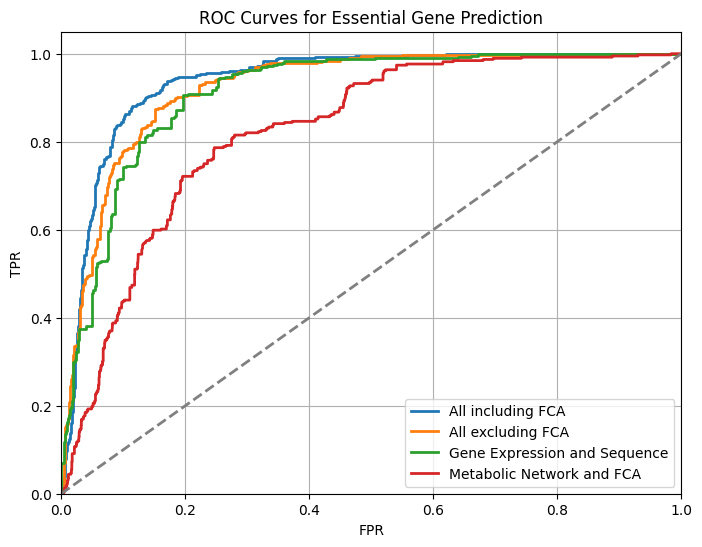

In [ ]:
def plot_multi_roc_curve(roc_data_dict, title='ROC Curve for Test Data'):
    """
    Plot multiple ROC curves on one figure.

    Parameters:
        roc_data_dict (dict): A dictionary where each key is a model name and each value
                              is a dictionary with keys "fpr", "tpr", and "roc_auc".
        title (str): Title for the plot.
    """
    plt.figure(figsize=(8, 6))

    for label, roc_data in roc_data_dict.items():
        plt.plot(roc_data["fpr"], roc_data["tpr"], lw=2,
                 label=f'{label}')

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

# Call the plotting function using the generated roc_dict
plot_multi_roc_curve(roc_dict, title='ROC Curves for Essential Gene Prediction')

# Boxplots of 26 Selected Features by Class (Essential vs Non-Essential)

To reproduce the Boxplots in Figure 3, it is sufficient to directly read the `Table_S1.csv` file and plot the selected best features. This process is independent of the previous Performance evaluation and is carried out separately.

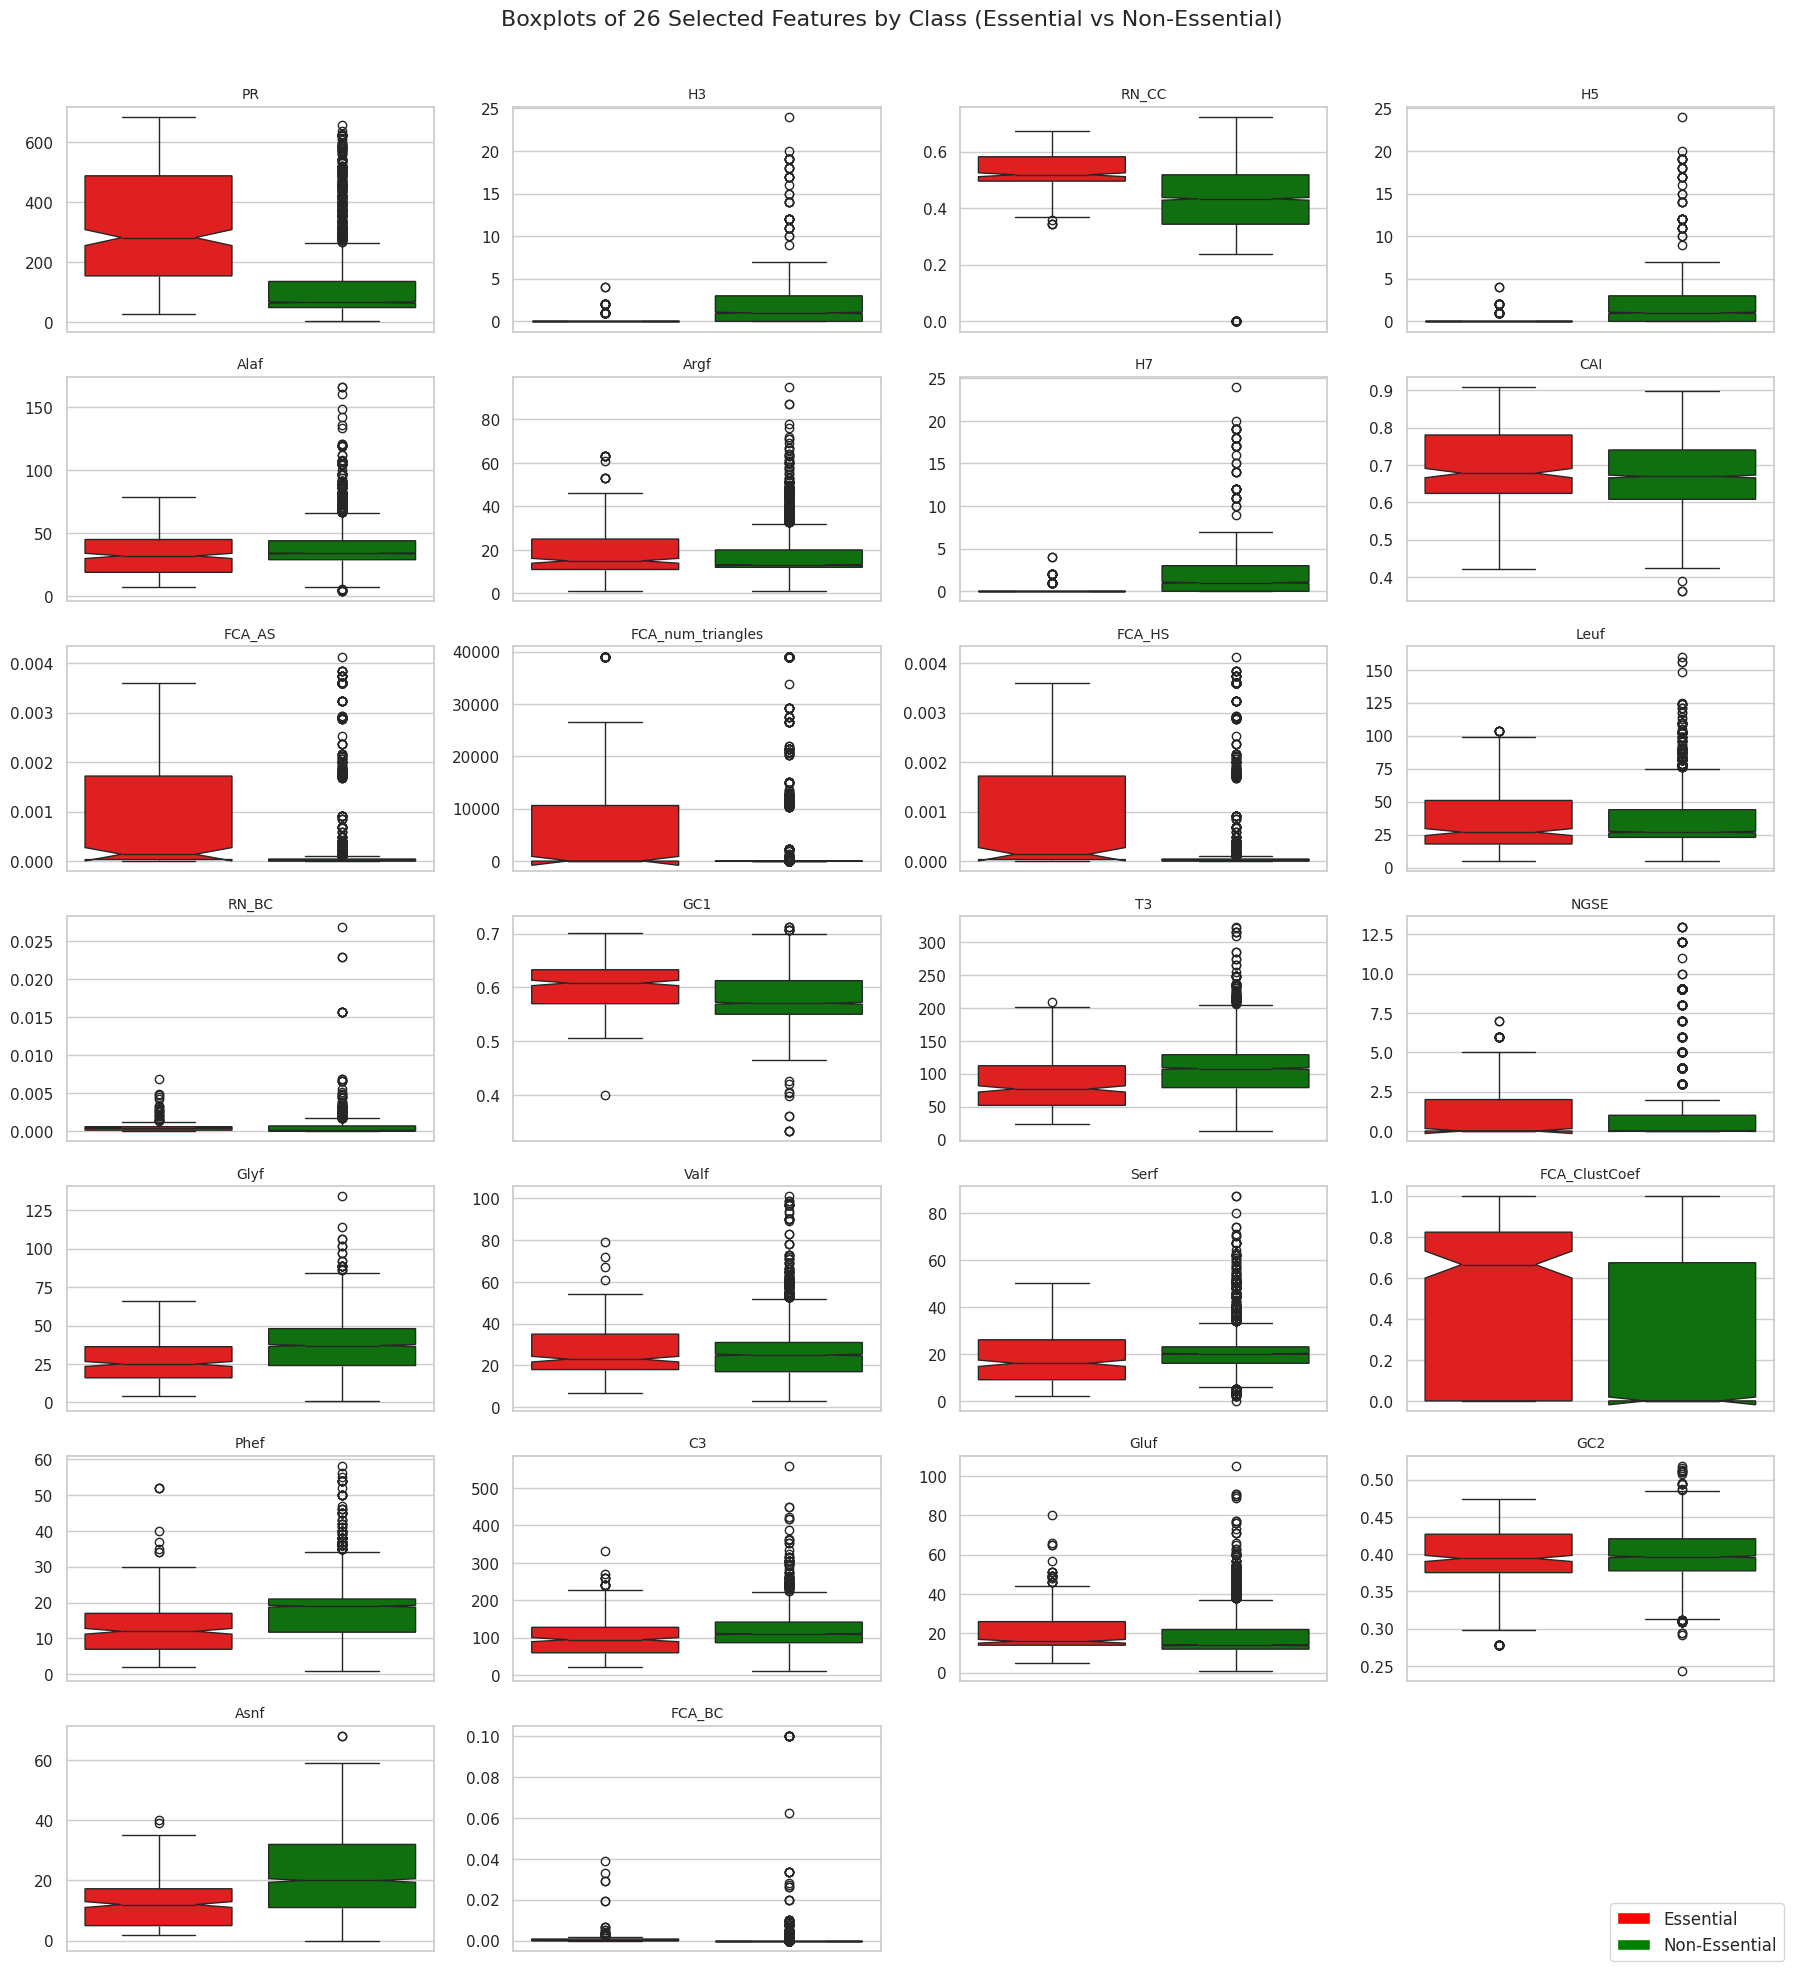

In [ ]:
# Read the CSV file into a pandas DataFrame.
df_test = pd.read_csv(path_test)

# Extract the list of features for the "All_including_FCA" group.
selected_features = feature_groups['All_including_FCA']

# Define the column name that contains the class labels.
label_col = 'Class'

# Map abbreviated class labels to full names:
# "E" is mapped to "Essential" and "N" is mapped to "Non-Essential".
label_mapping = {"E": "Essential", "N": "Non-Essential"}
df_test[label_col] = df_test[label_col].map(label_mapping)

# Set the overall aesthetic style for the plots.
sns.set(style="whitegrid")

# Create a figure with a grid layout (7 rows x 4 columns) for the boxplots.
plt.figure(figsize=(18, 20))

# Specify the desired order for x-axis and hue.
order_list = ["Essential", "Non-Essential"]

# Loop through each feature in the selected feature group to create individual boxplots.
for idx, feature in enumerate(selected_features):
    # Skip this feature if it does not exist in the DataFrame.
    if feature not in df_test.columns:
        continue

    # Create a subplot for the current feature.
    plt.subplot(7, 4, idx + 1)

    # For FCA_BC feature, clip data to 0.1
    if feature == "FCA_BC":
        data_to_plot = df_test.copy()
        data_to_plot[feature] = data_to_plot[feature].clip(upper=0.1)
    else:
        data_to_plot = df_test

    # Draw the boxplot:
    # - 'x' and 'hue' are both set to the class label column.
    # - order and hue_order ensure that Essential (red) is on the left and Non-Essential (green) on the right.
    sns.boxplot(
        x=label_col,
        y=feature,
        data=data_to_plot,
        order=order_list,
        hue=label_col,
        hue_order=order_list,
        palette={"Essential": "red", "Non-Essential": "green"},
        whis=1.5,
        notch=True,
        dodge=False
    )

    # Remove the subplot legend (we will add a single overall legend later).
    plt.legend([], [], frameon=False)

    # Set the title of the subplot to the current feature's name.
    plt.title(feature, fontsize=10)

    # Remove axis labels and tick labels to reduce clutter.
    plt.xlabel("")
    plt.ylabel("")
    plt.xticks([])

# Adjust the layout to prevent overlapping subplots.
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for the overall title

# Create an overall legend using custom patches.
legend_handles = [
    Patch(facecolor="red", label="Essential"),
    Patch(facecolor="green", label="Non-Essential")
]
# Position the overall legend at the bottom-right corner.
plt.figlegend(handles=legend_handles, loc='lower right', bbox_to_anchor=(1, 0), ncol=1, fontsize=12)

# Set a super-title for the entire figure.
plt.suptitle(
    "Boxplots of 26 Selected Features by Class (Essential vs Non-Essential)",
    fontsize=16,
    y=0.98
)

# Display the final figure.
plt.show()